In [5]:
import matplotlib.pyplot as plt
import pandas as pd
import statsmodels.api as sm


df = pd.read_excel("Laboratorio 1. Series de Tiempo 2026 - Base_Migracion_2009-2026jun.xlsx")
top_3_paises = (
    df.groupby("País")["Viajero"]
    .sum()
    .nlargest(3)
    .index.tolist()
)
print(f"Los 3 países con mayor número de viajeros son: {top_3_paises}")

df["Fecha"] = pd.to_datetime(
    df["Año"].astype(str) + "-" + df["Mes cod"].astype(str) + "-01"
)



series_paises = {}
for pais in top_3_paises:
    df_pais = df[df["País"] == pais]
    serie_mensual = df_pais.groupby("Fecha")["Viajero"].sum()
    serie_mensual = serie_mensual.asfreq("MS").fillna(0)
    series_paises[pais] = serie_mensual
    print(
        f"Serie temporal para {pais} creada con {len(serie_mensual)} meses."
    )


#Index(['Año', 'Mes cod', 'Mes', 'Vía', 'Frontera', 'País', 'Región',
    #   'Región dos', 'Regiones OMT', 'MCEO', 'Agrupación Residencia',
     #  'Tipo de Viajero', 'Viajero'],


# Los 3 países con mayor número de viajeros son: ['El Salvador', 'Guatemala', 'Estados Unidos de América']
# Serie temporal para El Salvador creada con 210 meses.
# Serie temporal para Guatemala creada con 168 meses.
# Serie temporal para Estados Unidos de América creada con 210 meses.



Los 3 países con mayor número de viajeros son: ['El Salvador', 'Guatemala', 'Estados Unidos de América']
Serie temporal para El Salvador creada con 210 meses.
Serie temporal para Guatemala creada con 168 meses.
Serie temporal para Estados Unidos de América creada con 210 meses.



Entrenando SARIMA para: El Salvador


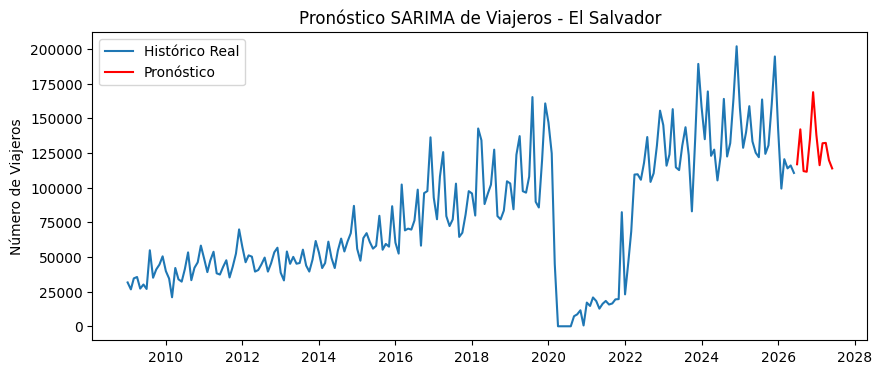


Entrenando SARIMA para: Guatemala


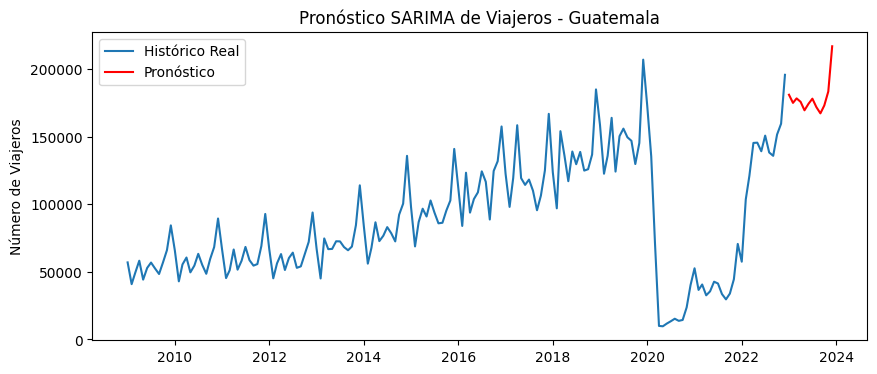


Entrenando SARIMA para: Estados Unidos de América


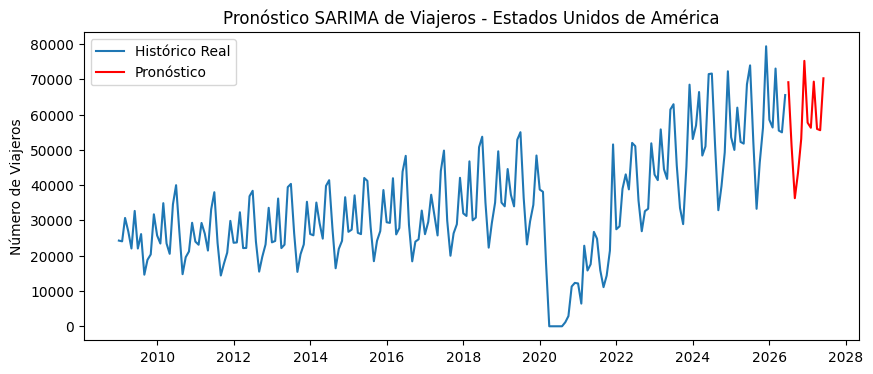

In [6]:
import matplotlib.pyplot as plt
import statsmodels.api as sm

for pais, serie in series_paises.items():
    print(f"\nEntrenando SARIMA para: {pais}")
    modelo = sm.tsa.statespace.SARIMAX(
        serie,
        order=(1, 1, 1),
        seasonal_order=(1, 1, 1, 12),
        enforce_stationarity=False,
        enforce_invertibility=False,
    )
    resultado = modelo.fit(disp=False)
    pronostico = resultado.get_forecast(steps=12).predicted_mean

    plt.figure(figsize=(10, 4))
    plt.plot(serie.index, serie, label="Histórico Real")
    plt.plot(pronostico.index, pronostico, label="Pronóstico", color="red")
    plt.title(f"Pronóstico SARIMA de Viajeros - {pais}")
    plt.ylabel("Número de Viajeros")
    plt.legend()
    plt.show()
